# Worksheet 8 - Aranya Mukherjee(23MS261)

## Q1 : Cooling a Hot Rod with Fixed-End Temperatures

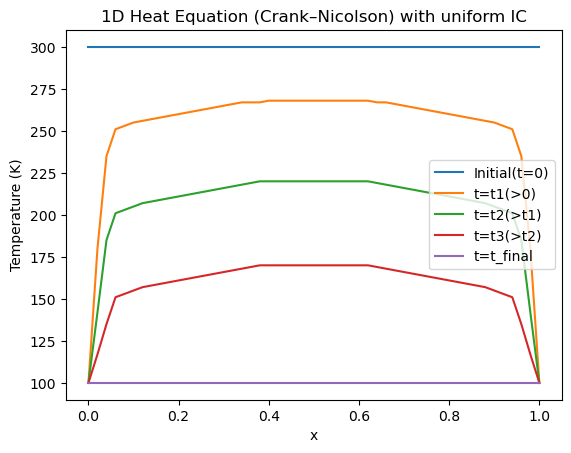

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def thomas_solve1(a, b, c, d):
    """Thomas Algorithm to solve tridiagonal system A x = d."""
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1]/b[i-1]
        b[i]   = b[i]   - w*c[i-1]
        d[i]   = d[i]   - w*d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1]/b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1])/b[i]
    return x

# -------------------------------
# Parameters
# -------------------------------
L      = 1.0      # rod length
Nx     = 51       # spatial distance steps
dx     = L/(Nx-1)
alpha  = 1e-4
dt     = 0.1
Nt     = 5000     # time steps
r      = alpha*dt/dx**2

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T_left = 100
T_right= 100              # Left and right ends kept at same temperature

T = np.full(Nx, 300)
# Rod is initially at a uniform temperature of 300 K

# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()] #records heat profiles at different temperatures

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary from time n => + (r/2)* T_left or T_right
    # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
    # Summed = r* T_left, r* T_right for the first/last interior row
    RHS[0]    += r * T_left     # i=1 sees boundary at x=0
    RHS[-1]   += r * T_right    # i=Nx-2 sees boundary at x=L
#Enforces u(0,t)=T0 and u(L,t)=T0 at every step
    
    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve1(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    time_history.append(T.copy())

# Plot evolution of Temperature profiles of rod
plt.plot(x, time_history[0], label='Initial(t=0)')
plt.plot(x, time_history[50], label='t=t1(>0)')
plt.plot(x, time_history[100], label='t=t2(>t1)')
plt.plot(x, time_history[150], label='t=t3(>t2)')
plt.plot(x, time_history[-1], label='t=t_final')
#plt.plot(x, T, label='Final')
plt.xlabel('x')
plt.ylabel('Temperature (K)')
plt.title('1D Heat Equation (Crank–Nicolson) with uniform IC')
plt.legend()
plt.show()


 Observation: Rod starts cooling from ends to the middle. Heat diffuses outward. 
 Long time solution(t $\to \, \infty$) u = 100 K

## Q2: Heating with Different Dirichlet Temperatures at Each End

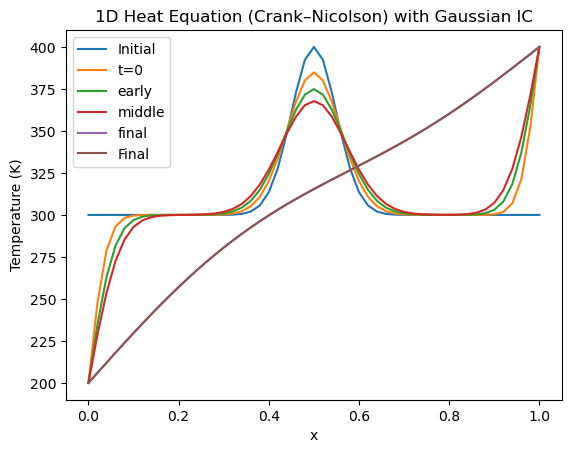

In [17]:

def thomas_solve2(a, b, c, d):
    """Thomas Algorithm to solve tridiagonal system A x = d."""
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1]/b[i-1]
        b[i]   = b[i]   - w*c[i-1]
        d[i]   = d[i]   - w*d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1]/b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1])/b[i]
    return x

# -------------------------------
# Parameters
# -------------------------------
L      = 1.0      # rod length
Nx     = 51
dx     = L/(Nx-1)
alpha  = 1e-4
dt     = 0.1
Nt     = 5000
r      = alpha*dt/dx**2

# Spatial grid
x = np.linspace(0, L, Nx)

# Dirichlet boundaries
T_left = 200.0
T_right= 400.0

# Gaussian initial condition
T = np.full(Nx, 300.0)
sigma = 0.05
peak_amplitude = 100.0  # so peak is 300 + 100 = 400
for i in range(Nx):
    T[i] += peak_amplitude * np.exp(-(x[i] - 0.5*L)**2 / (2*sigma**2))

# Construct A and B for interior nodes i=1..Nx-2
n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior,    1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1,  r/2)
b_B = np.full(n_interior,    1 - r)
c_B = np.full(n_interior-1,  r/2)

time_history = [T.copy()]

for n in range(Nt):
    T_old = T.copy()
    
    # 1) Form the RHS = B * T_old_interior + boundary terms
    T_in = T_old[1:-1]  # interior
    RHS = np.zeros(n_interior)

    # Multiply B*T_in
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]

    # Boundary from time n => + (r/2)* T_left or T_right
    # Boundary from time n+1 => also + (r/2)* T_left, T_right on the RHS
    # Summed = r* T_left, r* T_right for the first/last interior row
    RHS[0]    += r * T_left     # i=1 sees boundary at x=0
    RHS[-1]   += r * T_right    # i=Nx-2 sees boundary at x=L

    # 2) Solve A * T_in^{new} = RHS
    sol = thomas_solve2(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())

    # 3) Put interior solution back + Dirichlet boundary
    T[1:-1] = sol
    T[0]    = T_left
    T[-1]   = T_right

    time_history.append(T.copy())

# Plot evolution of temperature profiles of rod
plt.plot(x, time_history[0], label='Initial')
plt.plot(x, time_history[50], label='t=0')
plt.plot(x, time_history[100], label='early')
plt.plot(x, time_history[150], label='middle')
plt.plot(x, time_history[-1], label='final')
#plt.plot(x, T, label='Final')
plt.plot(x, T, label='Final')
plt.xlabel('x')
plt.ylabel('Temperature (K)')
plt.title('1D Heat Equation (Crank–Nicolson) with Gaussian IC')
plt.legend()
plt.show()


Higher $\Delta t$ results in lesser temporal resolution. Reduces accuracy

Smaller $\Delta x$ results in more spatial resolution, profiles become smoother. 

Higher 